# Performance Notebook



## Lecture 04


### Milestone 1 Refractor code


In [ ]:
from mandelbort import compute_mandelbrot_numba, mandelbrot_serial, run_algorithms

In [6]:
n_runs = 5

algorithms = {
"numba": lambda res: compute_mandelbrot_numba(-2, 1, -1.5, 1.5, res),
"numba_lecture4": lambda res: mandelbrot_serial(res, -2, 1, -1.5, 1.5, max_iter=100),
}
grid_res = [1024]

results, timings = run_algorithms(grid_res,algorithms,n_runs=n_runs)

 numba_Res_1024 with Median:0.0672s ( min =0.0665, max =0.0688)
 numba_lecture4_Res_1024 with Median:0.0649s ( min =0.0644, max =0.0656)


Can be seen that the 2 version indeed match based of timings

### Milestone 2-3

In [8]:
from mandelbort import mandelbrot_parallel

In [34]:
algorithms = {}
workers = [1,2,4,8,16]
grid_res = [1024]
n_runs = 3

for w in workers:
    name = f"parallel_workers_{w}"
    algorithms[name] = lambda res, w=w: mandelbrot_parallel(res, -2, 1, -1.5, 1.5,
                                                    n_workers=w,n_runs=n_runs,
                                                    meta_prefix=f"Numba parellel with workers = {w}")

results, timings = run_algorithms(grid_res,algorithms,n_runs=n_runs)

 Numba parellel with workers = 1 with Median:0.0723s ( min =0.0710, max =0.0762)
 Numba parellel with workers = 2 with Median:0.0381s ( min =0.0378, max =1.5656)
 Numba parellel with workers = 4 with Median:0.0334s ( min =0.0327, max =1.7013)
 Numba parellel with workers = 8 with Median:0.0216s ( min =0.0211, max =1.9301)
 Numba parellel with workers = 16 with Median:0.0153s ( min =0.0137, max =4.2796)


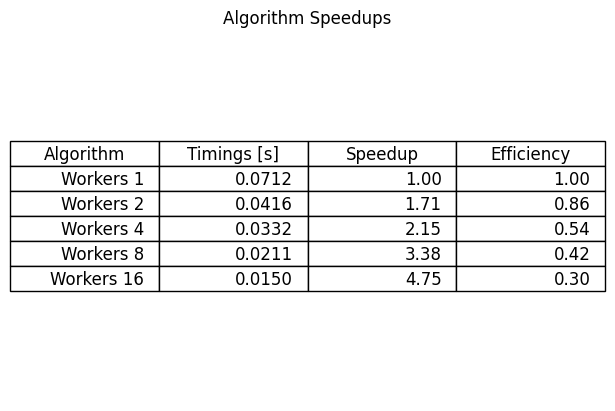

In [30]:
import matplotlib.pyplot as plt

speedups = {}
efficiency = {}
first_key = list(results[1024].keys())[0] 
reference_time = timings[1024][first_key]
for name, t in timings[1024].items():
        speedups[name] = reference_time / t
        n_workers = int(name.split("_")[-1])
        efficiency[name] = speedups[name] / n_workers

# table 
fig, axes = plt.subplots(1)

axes.axis("off")
table_data = []
for name in speedups.keys():
    s = speedups[name]
    e = efficiency.get(name, "")  # empty if efficiency doesn't exist
    t = timings[1024][name]
    table_data.append([
        f"Workers {(name.split("workers_")[1])}",
        f"{t:.4f}",
        f"{s:.2f}",
        f"{e:.2f}" if e != "" else "",
    ])
    table = axes.table(
        cellText=table_data,
        colLabels=["Algorithm","Timings [s]", "Speedup", "Efficiency"],
        loc="center"
    )
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)
axes.set_title("Algorithm Speedups")

plt.show()

Can be observed we indeed get an speedup over the multiple worker but it does not increase direct at maximum speedup which are seen but by speed up and effiency

## Lecture 05

## Milestone 1

In [ ]:
workers = [1,2,4,8,16]
grid_res = [1024]
n_runs = 3
algorithms ={ "parallel_workers_1": lambda res: mandelbrot_parallel(res, -2, 1, -1.5, 1.5,
                                                    n_workers=1,n_runs=n_runs,n_chunks = 1,
                                                    meta_prefix=f"Numba parellel with workers = 1")
}

for w in workers:
        name = f"parallel_chunk_{w*4}x_worker_{w}"
        algorithms[name] = lambda res, w=w: mandelbrot_parallel(res, -2, 1, -1.5, 1.5, 
                                                                n_workers=w,n_runs=n_runs,n_chunks=n_workers*4,
                                                                meta_prefix=f"Numba parellel {w*4} chunks with workers = {w}")

results, timings = run_algorithms(grid_res,algorithms,n_runs=n_runs)

 Numba parellel with workers = 16 with Median:0.0721s ( min =0.0717, max =0.0725)
 Numba parellel 4 chunks with workers = 1 with Median:0.0744s ( min =0.0738, max =0.0757)
 Numba parellel 8 chunks with workers = 2 with Median:0.0355s ( min =0.0351, max =1.5393)
 Numba parellel 16 chunks with workers = 4 with Median:0.0189s ( min =0.0178, max =1.6359)
 Numba parellel 32 chunks with workers = 8 with Median:0.0117s ( min =0.0113, max =2.0742)
 Numba parellel 64 chunks with workers = 16 with Median:0.0138s ( min =0.0133, max =4.6072)


## Milestone 2

In [105]:
n_worker_all = [1, 2, 4, 8]

grid_res = [1024]
max_cores = max_workers = max(n_worker_all)

chunks = [max_cores * x for x in [1,2,4,8,16]]

algorithms ={ "parallel_workers_1": lambda res: mandelbrot_parallel(res, -2, 1, -1.5, 1.5,
                                                    n_workers=1,n_runs=n_runs,n_chunks = 1,
                                                    meta_prefix=f"Numba parellel with workers = 1")
}

for c in chunks:
        name = f"parallel_chunk_{c}_workers_{max_cores}"
        algorithms[name] = lambda res, c=c: mandelbrot_parallel(res, -2, 1, -1.5, 1.5, 
                                                                n_workers=max_cores,n_runs=n_runs,n_chunks=c,
                                                                meta_prefix=f"Numba parellel {c} chunks with workers = {max_cores}")

results, timings = run_algorithms(grid_res,algorithms,n_runs=n_runs)

first_key = list(results[1024].keys())[0] 
naive_time = timings[1024][first_key]
T1 = timings[1024]["parallel_workers_1"]

lif = {}
speedups = {}
efficiency = {}
for name, t in timings[1024].items():
    speedups[name] = naive_time / t
    # compute efficiency only for parallel runs
    if "parallel" in name:
        # extract worker count from the name, e.g., 'parallel_lecture4_4' -> 4
        n_workers = int(name.split("workers_")[1])
        efficiency[name] = speedups[name] / n_workers
        lif[name] = n_workers * t / T1 - 1

 Numba parellel with workers = 1 with Median:0.0745s ( min =0.0741, max =0.0768)
 Numba parellel 8 chunks with workers = 8 with Median:0.0209s ( min =0.0208, max =2.1401)
 Numba parellel 16 chunks with workers = 8 with Median:0.0134s ( min =0.0131, max =2.3776)
 Numba parellel 32 chunks with workers = 8 with Median:0.0127s ( min =0.0127, max =2.4269)
 Numba parellel 64 chunks with workers = 8 with Median:0.0197s ( min =0.0153, max =2.1086)
 Numba parellel 128 chunks with workers = 8 with Median:0.0153s ( min =0.0139, max =2.1292)


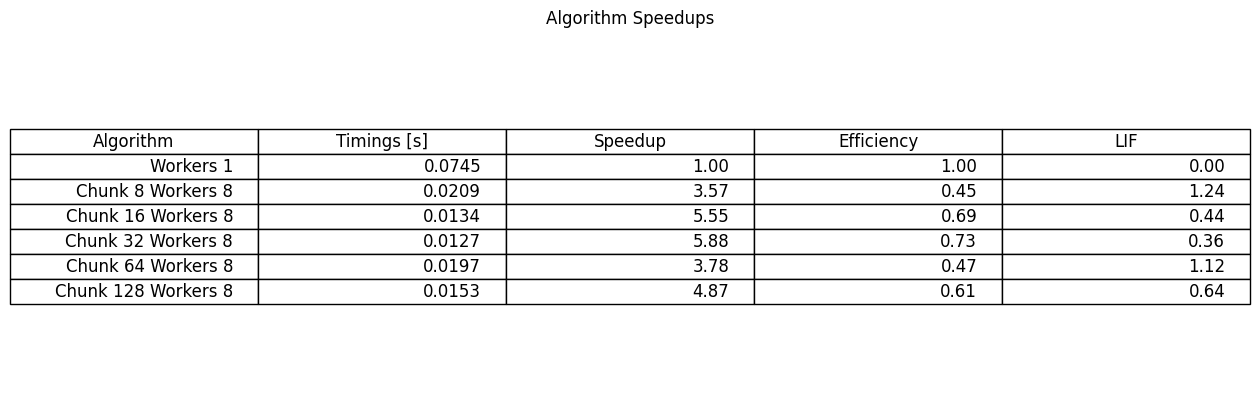

In [106]:
# create figure
fig, axes = plt.subplots(1)

# speedup table 
axes.axis("off")
table_data = []
for name in speedups.keys():
    s = speedups[name]
    e = efficiency.get(name, "")  # empty if efficiency doesn't exist
    l = lif.get(name, "")
    t = timings[1024][name]
    if "_chunk_" in name:
        name = f"Chunk {name.split("chunk_")[1].split("_")[0]} Workers {(name.split("workers_")[1])}"
    else:
        name = f"Workers {(name.split("workers_")[1])}"
    table_data.append([
        name,
        f"{t:.4f}",
        f"{s:.2f}",
        f"{e:.2f}" if e != "" else "",
        f"{l:.2f}" if l != "" else ""
    ])
    table = axes.table(
        cellText=table_data,
        colLabels=["Algorithm","Timings [s]", "Speedup", "Efficiency", "LIF"],
        loc="center"
    )
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(2.5, 1.5)
axes.set_title("Algorithm Speedups")

# im0 = axes[2].imshow(results[1024]["numba_lecture4"], cmap="hot")
# numba_lecture_time_1024= timings[1024]["numba_lecture4"]
# axes[2].set_title(f"Numba lecture 4 Mandelbrot\n Median time: {numba_lecture_time_1024:.2f} s")
# axes[2].axis("off")
# fig.colorbar(im0, ax=axes[2], fraction=0.046, pad=0.04)

plt.show()

In [107]:
 # Choose Optimal Chunk size for max cores
chunk_lif = {k: v for k, v in lif.items() if "parallel_chunk" in k}
# Find the one with the lowest LIF
best_chunk_name = min(chunk_lif, key=chunk_lif.get)
best_lif = chunk_lif[best_chunk_name]
print(f"Best chunked algorithm: {best_chunk_name} with LIF = {best_lif:.4f}")


Best chunked algorithm: parallel_chunk_32_workers_8 with LIF = 0.3607


## Milestone 3

In [57]:
from mandelbort import compute_mandelbrot_naive,compute_mandelbrot_vectorized,compute_mandelbrot_numba,compute_mandelbrot_numba_parallel

In [118]:
grid_res = [1024]
n_runs = 3
# Extract the most optimal
n_chunks_opt= int(best_chunk_name.split("chunk_")[1].split("_")[0])
n_workers_opt = int(best_chunk_name.split("workers_")[1])

performance_note_algorithms = {
"naive": lambda res: compute_mandelbrot_naive(-2, 1, -1.5, 1.5, res),
"vectorized": lambda res: compute_mandelbrot_vectorized(-2, 1, -1.5, 1.5, res),
"numba": lambda res: compute_mandelbrot_numba(-2, 1, -1.5, 1.5, res),
"numba_parellel": lambda res: compute_mandelbrot_numba_parallel(-2, 1, -1.5, 1.5, res),
"parallel_workers_1": lambda res: mandelbrot_parallel(res, -2, 1, -1.5, 1.5,
                                                    n_workers=1,n_runs=n_runs,
                                                    meta_prefix="Numba parellel with workers = 1"),
f"parallel_chunk_{n_chunks_opt}_workers_{n_workers_opt}": lambda res: mandelbrot_parallel(res, -2, 1, -1.5, 1.5,
                                                    n_workers=n_workers_opt,n_runs=n_runs,n_chunks=n_chunks_opt,
                                                    meta_prefix=f"Numba parellel {n_chunks_opt} with workers = {n_workers_opt}"),
}

results, timings = run_algorithms(grid_res,performance_note_algorithms,n_runs=n_runs)

 naive_Res_1024 with Median:6.8316s ( min =6.7285, max =7.0619)
 vectorized_Res_1024 with Median:1.3507s ( min =1.3414, max =1.3728)
 numba_Res_1024 with Median:0.0736s ( min =0.0700, max =0.0787)
 numba_parellel_Res_1024 with Median:0.0233s ( min =0.0231, max =0.0242)
 Numba parellel with workers = 1 with Median:0.0700s ( min =0.0687, max =0.0723)
 Numba parellel 32 with workers = 8 with Median:0.0117s ( min =0.0115, max =1.9053)


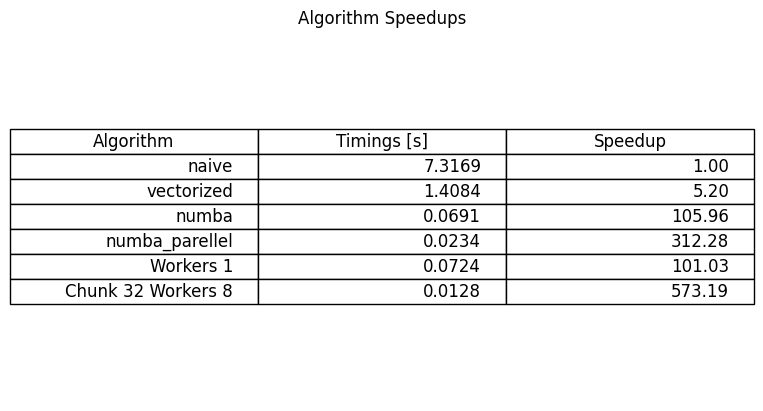

In [109]:
first_key = list(results[1024].keys())[0] 
naive_time = timings[1024][first_key]

speedups = {}
efficiency = {}
for name, t in timings[1024].items():
    speedups[name] = naive_time / t
    # compute efficiency only for parallel runs

# create figure
fig, axes = plt.subplots(1)

# speedup table 
axes.axis("off")
table_data = []
for name in speedups.keys():
    s = speedups[name]
    t = timings[1024][name]
    if "_chunk_" in name:
        name = f"Chunk {name.split("chunk_")[1].split("_")[0]} Workers {(name.split("workers_")[1])}"
    elif "_workers_" in name:
        name = f"Workers {(name.split("workers_")[1])}"
    else:
        name = name
    table_data.append([
        name,
        f"{t:.4f}",
        f"{s:.2f}",
    ])
    table = axes.table(
        cellText=table_data,
        colLabels=["Algorithm","Timings [s]", "Speedup"],
        loc="center"
    )
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 1.5)
axes.set_title("Algorithm Speedups")

# im0 = axes[2].imshow(results[1024]["numba_lecture4"], cmap="hot")
# numba_lecture_time_1024= timings[1024]["numba_lecture4"]
# axes[2].set_title(f"Numba lecture 4 Mandelbrot\n Median time: {numba_lecture_time_1024:.2f} s")
# axes[2].axis("off")
# fig.colorbar(im0, ax=axes[2], fraction=0.046, pad=0.04)

plt.show()

## Milestone 3

The once shown in all previous milestones include a warmup within which is not measured
When talking about the mandelbort_parallel

# Lecture 06

### Milestone 1

In [81]:
from mandelbort import mandelbrot_dask,run_algorithms

In [83]:
grid_res = [1024]
n_runs = 3
algorithms = {
"dask_chunk_1_worker_8": lambda res: mandelbrot_dask(res, -2, 1, -1.5, 1.5,
                                                        meta_prefix="dask Numba 1 x chunks with workers = 8")
}

results, timings = run_algorithms(grid_res,algorithms,n_runs=n_runs)


 dask_chunk_1_worker_8_Res_1024 with Median:0.0749s ( min =0.0746, max =0.0756)


### Milestone 2

In [113]:
chunk_dask = [1, 2, 4, 8, 16, 32, 64]
grid_res = [1024]
n_runs = 3
algorithms = {
"parallel_workers_1": lambda res: mandelbrot_parallel(res, -2, 1, -1.5, 1.5,
                                                        n_workers=1,n_runs=n_runs,
                                                        meta_prefix="Numba parellel with workers = 1")
}

for c in chunk_dask:
    name = f"dask_chunk_{c}_workers_8"
    algorithms[name] = lambda res, c=c: mandelbrot_dask(res, -2, 1, -1.5, 1.5,n_chunks=c,
                                                    meta_prefix="dask Numba {c} x chunks with workers = 8")

results, timings = run_algorithms(grid_res,algorithms,n_runs=n_runs)

first_key = list(results[1024].keys())[0] 
naive_time = timings[1024][first_key]
T1 = timings[1024]["parallel_workers_1"]
lif = {}
speedups = {}
efficiency = {}
for name, t in timings[1024].items():
    speedups[name] = naive_time / t
    # compute efficiency only for parallel runs
    if "parallel" or "dask" in name:
        n_workers = int(name.split("workers_")[1])
        efficiency[name] = speedups[name] / n_workers
        lif[name] = n_workers * t / T1 - 1

 Numba parellel with workers = 1 with Median:0.0750s ( min =0.0709, max =0.0758)
 dask_chunk_1_workers_8_Res_1024 with Median:0.0667s ( min =0.0658, max =0.0681)
 dask_chunk_2_workers_8_Res_1024 with Median:0.0695s ( min =0.0692, max =0.0733)
 dask_chunk_4_workers_8_Res_1024 with Median:0.0693s ( min =0.0677, max =0.0720)
 dask_chunk_8_workers_8_Res_1024 with Median:0.0706s ( min =0.0671, max =0.0731)
 dask_chunk_16_workers_8_Res_1024 with Median:0.0723s ( min =0.0717, max =0.0723)
 dask_chunk_32_workers_8_Res_1024 with Median:0.0779s ( min =0.0756, max =0.0782)
 dask_chunk_64_workers_8_Res_1024 with Median:0.0891s ( min =0.0860, max =0.0906)


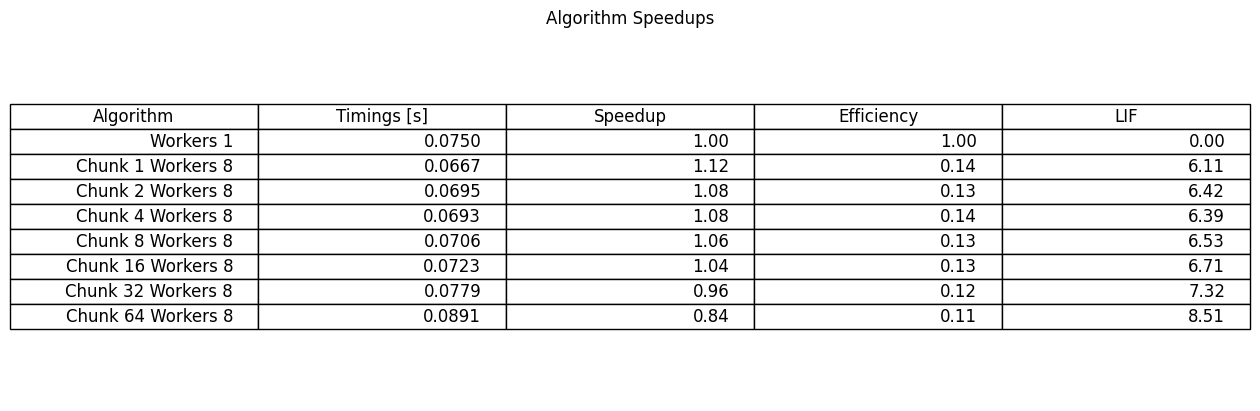

In [114]:
# create figure
fig, axes = plt.subplots(1)

# speedup table 
axes.axis("off")
table_data = []
for name in speedups.keys():
    s = speedups[name]
    e = efficiency.get(name, "")  # empty if efficiency doesn't exist
    l = lif.get(name, "")
    t = timings[1024][name]
    if "_chunk_" in name:
        name = f"Chunk {name.split("chunk_")[1].split("_")[0]} Workers {(name.split("workers_")[1])}"
    else:
        name = f"Workers {(name.split("workers_")[1])}"
    table_data.append([
        name,
        f"{t:.4f}",
        f"{s:.2f}",
        f"{e:.2f}" if e != "" else "",
        f"{l:.2f}" if l != "" else ""
    ])
    table = axes.table(
        cellText=table_data,
        colLabels=["Algorithm","Timings [s]", "Speedup", "Efficiency", "LIF"],
        loc="center"
    )
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(2.5, 1.5)
axes.set_title("Algorithm Speedups")

# im0 = axes[2].imshow(results[1024]["numba_lecture4"], cmap="hot")
# numba_lecture_time_1024= timings[1024]["numba_lecture4"]
# axes[2].set_title(f"Numba lecture 4 Mandelbrot\n Median time: {numba_lecture_time_1024:.2f} s")
# axes[2].axis("off")
# fig.colorbar(im0, ax=axes[2], fraction=0.046, pad=0.04)

plt.show()

In [119]:
# Choose Optimal Chunk size for max cores
chunk_lif_dask = {k: v for k, v in lif.items() if "dask_chunk" in k}
# Find the one with the lowest LIF
best_chunk_name_dask = min(chunk_lif_dask, key=chunk_lif_dask.get)
best_lif_dask = chunk_lif_dask[best_chunk_name_dask]
n_chunks_dask_opt = best_chunk_name_dask.split("chunk_")[1].split("_")[0]
print(f"Best Dask chunked algorithm: {best_chunk_name_dask} with Chunks = {n_chunks_dask_opt} and LIF = {best_lif_dask:.4f}")

Best Dask chunked algorithm: dask_chunk_1_workers_8 with Chunks = 1 and LIF = 6.1144


### Milestone 3


 naive_Res_1024 with Median:7.1278s ( min =7.1168, max =7.6397)
 vectorized_Res_1024 with Median:1.3268s ( min =1.3108, max =1.3800)
 numba_Res_1024 with Median:0.0698s ( min =0.0669, max =0.0698)
 numba_parellel_Res_1024 with Median:0.0228s ( min =0.0216, max =0.0231)
 Numba parellel with workers = 1 with Median:0.0727s ( min =0.0710, max =0.0729)
 Numba parellel 32 with workers = 8 with Median:0.0146s ( min =0.0135, max =1.9988)
 dask_chunk_1_workers_8_Res_1024 with Median:0.0707s ( min =0.0673, max =0.0717)


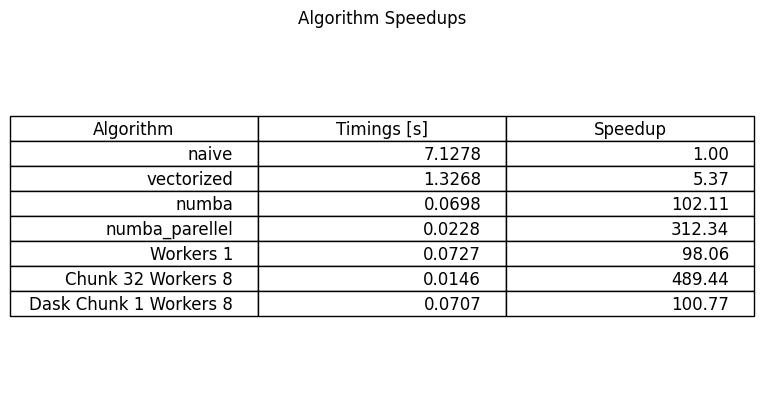

In [120]:
n_chunks_opt_dask= int(best_chunk_name_dask.split("chunk_")[1].split("_")[0])
n_workers_opt_dask = int(best_chunk_name_dask.split("workers_")[1])
performance_note_algorithms[f"dask_chunk_{n_chunks_opt_dask}_workers_{n_workers_opt_dask}"] = \
    lambda res: mandelbrot_dask(
        res, -2, 1, -1.5, 1.5,
        n_chunks=n_chunks_opt_dask,
        meta_prefix=f"dask Numba {n_chunks_opt_dask} x chunks with workers = {n_workers_opt_dask}"
    )

results, timings = run_algorithms(grid_res,performance_note_algorithms,n_runs=n_runs)

first_key = list(results[1024].keys())[0] 
naive_time = timings[1024][first_key]

speedups = {}
efficiency = {}
for name, t in timings[1024].items():
    speedups[name] = naive_time / t
    # compute efficiency only for parallel runs

# create figure
fig, axes = plt.subplots(1)

# speedup table 
axes.axis("off")
table_data = []
for name in speedups.keys():
    s = speedups[name]
    t = timings[1024][name]
    if "dask_chunk_" in name:
        name = f"Dask Chunk {name.split("chunk_")[1].split("_")[0]} Workers {(name.split("workers_")[1])}"
    elif "_chunk_" in name:
        name = f"Chunk {name.split("chunk_")[1].split("_")[0]} Workers {(name.split("workers_")[1])}"
    elif "_workers_" in name:
        name = f"Workers {(name.split("workers_")[1])}"
    else:
        name = name
    table_data.append([
        name,
        f"{t:.4f}",
        f"{s:.2f}",
    ])
    table = axes.table(
        cellText=table_data,
        colLabels=["Algorithm","Timings [s]", "Speedup"],
        loc="center"
    )
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 1.5)
axes.set_title("Algorithm Speedups")

# im0 = axes[2].imshow(results[1024]["numba_lecture4"], cmap="hot")
# numba_lecture_time_1024= timings[1024]["numba_lecture4"]
# axes[2].set_title(f"Numba lecture 4 Mandelbrot\n Median time: {numba_lecture_time_1024:.2f} s")
# axes[2].axis("off")
# fig.colorbar(im0, ax=axes[2], fraction=0.046, pad=0.04)

plt.show()